# LOAD THE DATASET

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import zipfile

zip_path = "/content/drive/MyDrive/Colab Notebooks/Plant Disease Detection/dataset/PlantVillage.zip"
extract_path = "/content/PlantVillage"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [9]:
import os

print(os.listdir("/content/PlantVillage"))

['PlantVillage']


In [10]:
base_path = "/content/PlantVillage/PlantVillage"

train_dir = base_path + "/train"
val_dir   = base_path + "/val"
test_dir  = base_path + "/test"

In [14]:
classes = os.listdir(base_path)

print("Total classes:", len(classes))
print(classes)

Total classes: 3
['train', 'val', 'test']


IMPORT IMAGE LOADER AND DEFINE IMAGE SETTINGS

In [16]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# DATA PREPROCESSING

In [17]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

TRAIN DATA WITH AUGMENTATION

In [18]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

VALIDATION + TEST (NO AUGMENTATION)

In [19]:
val_test_datagen = ImageDataGenerator(rescale=1./255)

LOAD TRAIN VAL AND TEST DATASETS

In [20]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 34771 images belonging to 38 classes.


In [21]:
val_data = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 10861 images belonging to 38 classes.


In [22]:
test_data = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 8673 images belonging to 38 classes.


# BUILD MOBILENETV2 (TRANSFER LEARNING MODEL)

In [23]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

In [24]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


FREEZE THE MODEL

In [25]:
base_model.trainable = False

BUILD CUSTOM CLASSIFIER

In [26]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(38, activation='softmax')
])

# COMPILE THE MODEL

In [27]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Phase: Learning basic disease patterns

MobileNetV2: extracting general features

Dense layers: slowly learning mapping

---



# TRAIN THE MODEL

In [29]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 445s 409ms/step - accuracy: 0.9308 - loss: 0.2022 - val_accuracy: 0.9456 - val_loss: 0.1627
Epoch 2/10
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 445s 410ms/step - accuracy: 0.9346 - loss: 0.1984 - val_accuracy: 0.9465 - val_loss: 0.1599
Epoch 3/10
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 437s 402ms/step - accuracy: 0.9357 - loss: 0.1902 - val_accuracy: 0.9511 - val_loss: 0.1418
Epoch 4/10
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 439s 404ms/step - accuracy: 0.9370 - loss: 0.1879 - val_accuracy: 0.9308 - val_loss: 0.2123
Epoch 5/10
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 440s 405ms/step - accuracy: 0.9388 - loss: 0.1796 - val_accuracy: 0.9476 - val_loss: 0.1532
Epoch 6/10
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 439s 404ms/step - accuracy: 0.9368 - loss: 0.1857 - val_accuracy: 0.9497 - val_loss: 0.1488
Epoch 7/10
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 441s 406ms/step - accuracy: 0.9384 - loss: 0.1754 - val_accuracy: 0.9461 - val_loss: 0.1537
Epoch 8/10
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 448s 412ms/step - ac

In [30]:
model.save("/content/drive/MyDrive/plant_disease_model.h5")

In [31]:
model.save("/content/drive/MyDrive/plant_disease_model.keras")

PLOT TRAINING CURVES

In [32]:
history.history

{'accuracy': [0.930804431438446,
  0.9345719218254089,
  0.9356935620307922,
  0.9369876980781555,
  0.9388283491134644,
  0.9367576241493225,
  0.9383969306945801,
  0.9402087926864624,
  0.9392021894454956,
  0.9388858675956726],
 'loss': [0.20219650864601135,
  0.19838735461235046,
  0.1901884227991104,
  0.1878606379032135,
  0.17959444224834442,
  0.18574084341526031,
  0.1753850132226944,
  0.1768036037683487,
  0.17328369617462158,
  0.17514492571353912],
 'val_accuracy': [0.9455851316452026,
  0.9465058445930481,
  0.9511094689369202,
  0.930761456489563,
  0.9476107358932495,
  0.9497283697128296,
  0.946137547492981,
  0.9448485374450684,
  0.9518460631370544,
  0.9504649639129639],
 'val_loss': [0.1627374291419983,
  0.15990608930587769,
  0.1418117880821228,
  0.2122819721698761,
  0.15315210819244385,
  0.1488153636455536,
  0.15372034907341003,
  0.16676439344882965,
  0.14481285214424133,
  0.14791688323020935]}

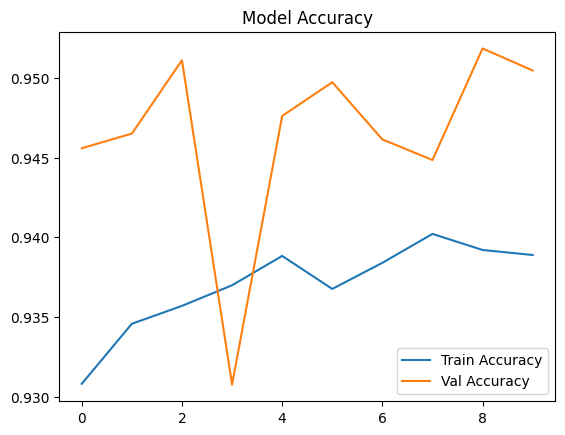

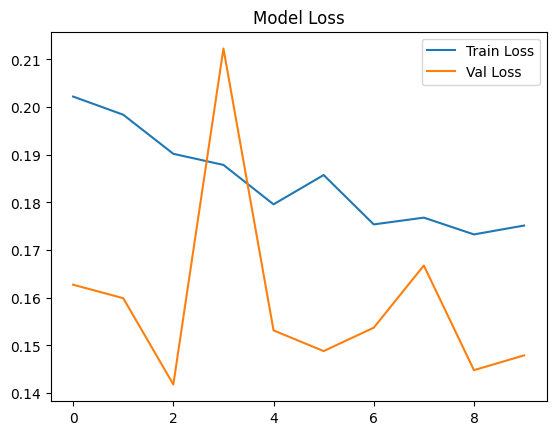

In [33]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

In [38]:
import shutil

shutil.copy(
    "/content/drive/MyDrive/plant_disease_model.keras",
    "/content/plant_disease_model.keras"
)

'/content/plant_disease_model.keras'

# EVALUATE MODEL ON TEST DATASET

In [14]:
test_loss, test_acc = model.evaluate(test_data)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

272/272 ━━━━━━━━━━━━━━━━━━━━ 4005s 15s/step - accuracy: 0.9526 - loss: 0.1435
Test Accuracy: 0.9526115655899048
Test Loss: 0.14352388679981232


# CONFUSION MATRIX

272/272 ━━━━━━━━━━━━━━━━━━━━ 4032s 15s/step


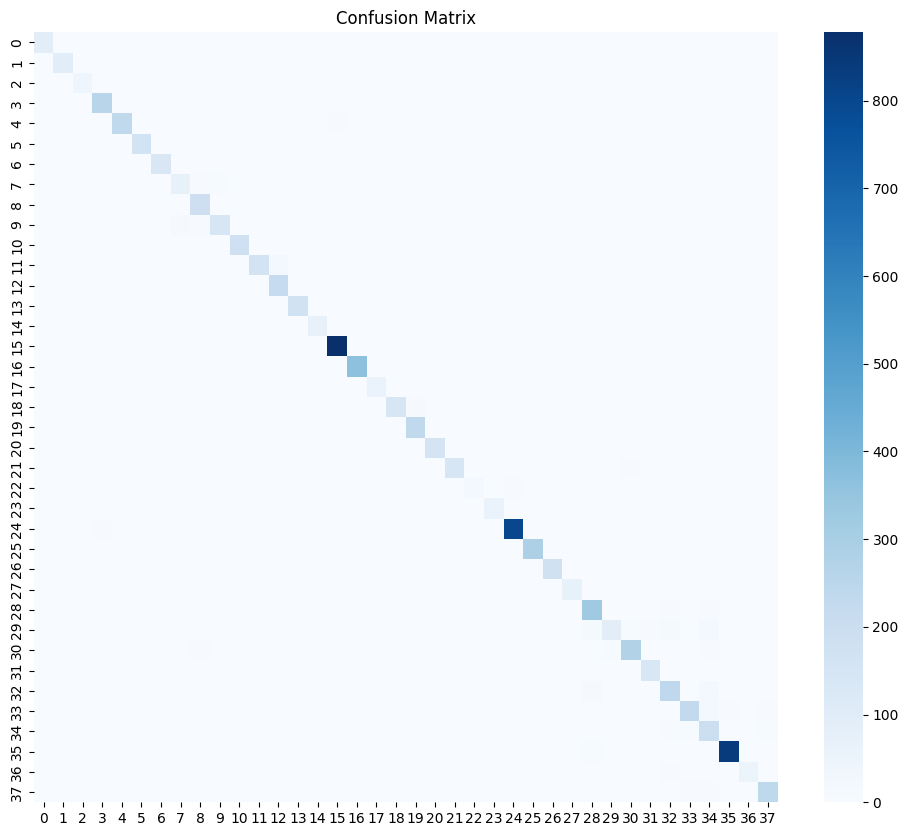

In [16]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

Y_pred = model.predict(test_data)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_data.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# CLASSIFICATION REPORT

In [17]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97       100
           1       0.92      1.00      0.96        99
           2       1.00      0.93      0.96        44
           3       0.96      0.98      0.97       263
           4       0.99      0.97      0.98       240
           5       1.00      0.99      0.99       168
           6       0.98      0.99      0.98       136
           7       0.87      0.87      0.87        82
           8       0.94      1.00      0.97       190
           9       0.95      0.90      0.93       157
          10       1.00      1.00      1.00       185
          11       1.00      0.88      0.94       188
          12       0.91      1.00      0.95       221
          13       1.00      0.99      0.99       172
          14       0.99      1.00      0.99        67
          15       0.99      1.00      0.99       881
          16       0.99      0.99      0.99       367
          17       0.98    

In [18]:
from sklearn.metrics import accuracy_score

print("Test Accuracy:", accuracy_score(y_true, y_pred))

Test Accuracy: 0.9526115530958146


# REAL-WORLD TEST (PREDICT SINGLE LEAF IMAGE)

In [19]:
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img = image.img_to_array(img)/255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)
    class_index = np.argmax(pred)

    return class_index

In [20]:
class_names = list(test_data.class_indices.keys())

# FINALIZE PREDICTION FUNCTION

In [21]:
def predict_disease(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img = image.img_to_array(img)/255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)
    return class_names[np.argmax(pred)]

In [25]:
from google.colab import files
uploaded = files.upload()

for file_name in uploaded.keys():
    print(predict_disease(file_name))

Saving 0f586b94-6c22-4cd7-8c47-4376c4d88226___JR_HL 9560.JPG to 0f586b94-6c22-4cd7-8c47-4376c4d88226___JR_HL 9560.JPG
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 568ms/step
Cherry_(including_sour)___healthy


# SAVE THE MODEL

In [24]:
model.save("/content/drive/MyDrive/plant_disease_final.keras")